In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
rl_df = pd.read_csv('../results/DQN.csv', index_col=0)[["charts/episodic_return", "_step", "global_step", "seed", "env_id"]]
rl_df.dropna(inplace=True)
rl_df.head()

,charts/episodic_return,_step,global_step,seed,env_id
3,-500.0,3,499.0,3,Acrobot-v1
4,-500.0,4,999.0,3,Acrobot-v1
5,-500.0,5,1499.0,3,Acrobot-v1
6,-500.0,6,1999.0,3,Acrobot-v1
7,-500.0,7,2499.0,3,Acrobot-v1


AttributeError: 'Line2D' object has no property 'errorbar'

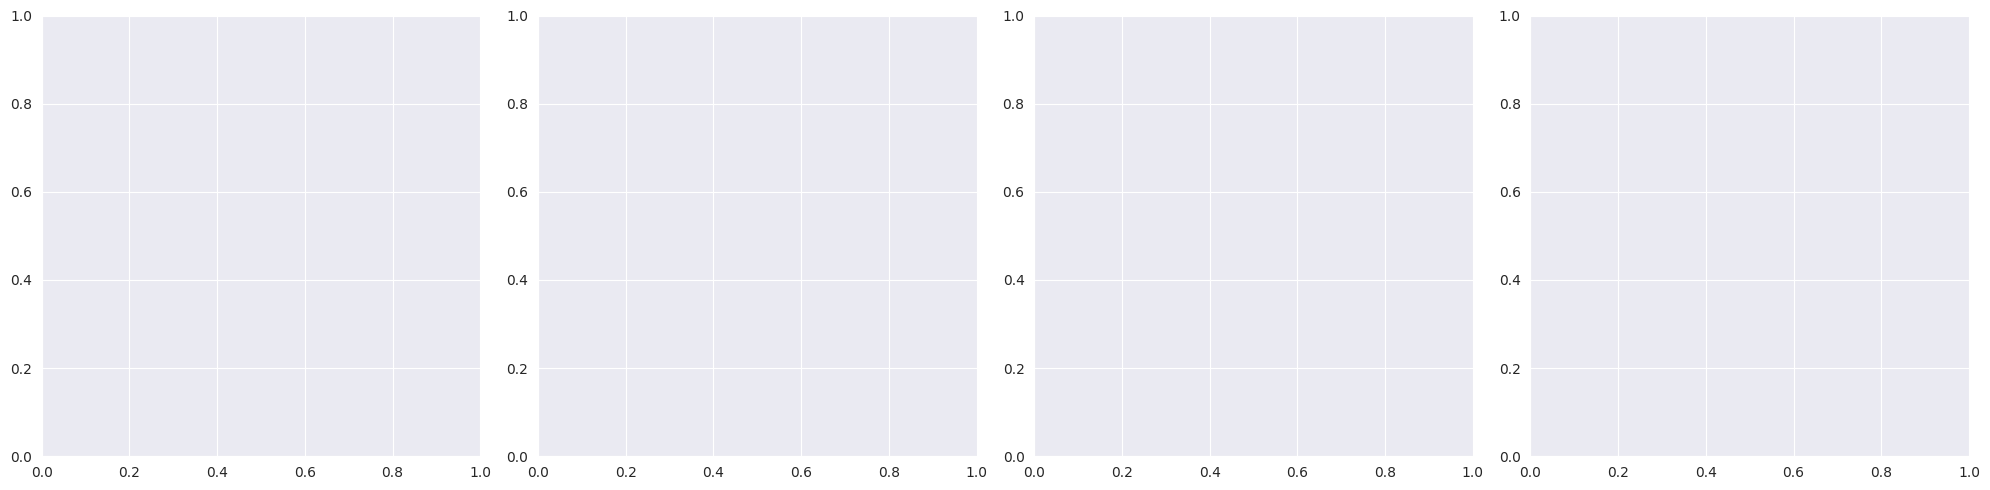

In [7]:
g = sns.relplot(
    data=rl_df,
    x="global_step",
    y="charts/episodic_return",
    col="env_id",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

In [8]:
discrete_envs = ["Acrobot-v1", "CartPole-v1", "LunarLander-v2", "MountainCar-v0"]
discrete_dfs = []
for env in discrete_envs:
    for seed in range(100, 109):
        for solver in ["lgp", "cgp"]:
            for ea in ["ga"]:
                processed_env_name = env.lower().split("-")[0]
                df = pd.read_csv(f"../results/ga_{solver}_{processed_env_name}_{seed}.csv")
                df["seed"] = seed
                df["ea"] = ea
                df["solver"] = solver
                df["problem"] = env
                df["env"] = processed_env_name
                discrete_dfs.append(df)
discrete_df = pd.concat(discrete_dfs, ignore_index=True)
discrete_df.head()

,iteration,fitness,time,seed,ea,solver,problem,env
0,0,-70.599998,1.57,100,ga,lgp,Acrobot-v1,acrobot
1,1,-98.000000,1.58,100,ga,lgp,Acrobot-v1,acrobot
2,2,-69.000000,1.52,100,ga,lgp,Acrobot-v1,acrobot
3,3,-69.400002,1.60,100,ga,lgp,Acrobot-v1,acrobot
4,4,-69.599998,1.59,100,ga,lgp,Acrobot-v1,acrobot


AttributeError: 'Line2D' object has no property 'errorbar'

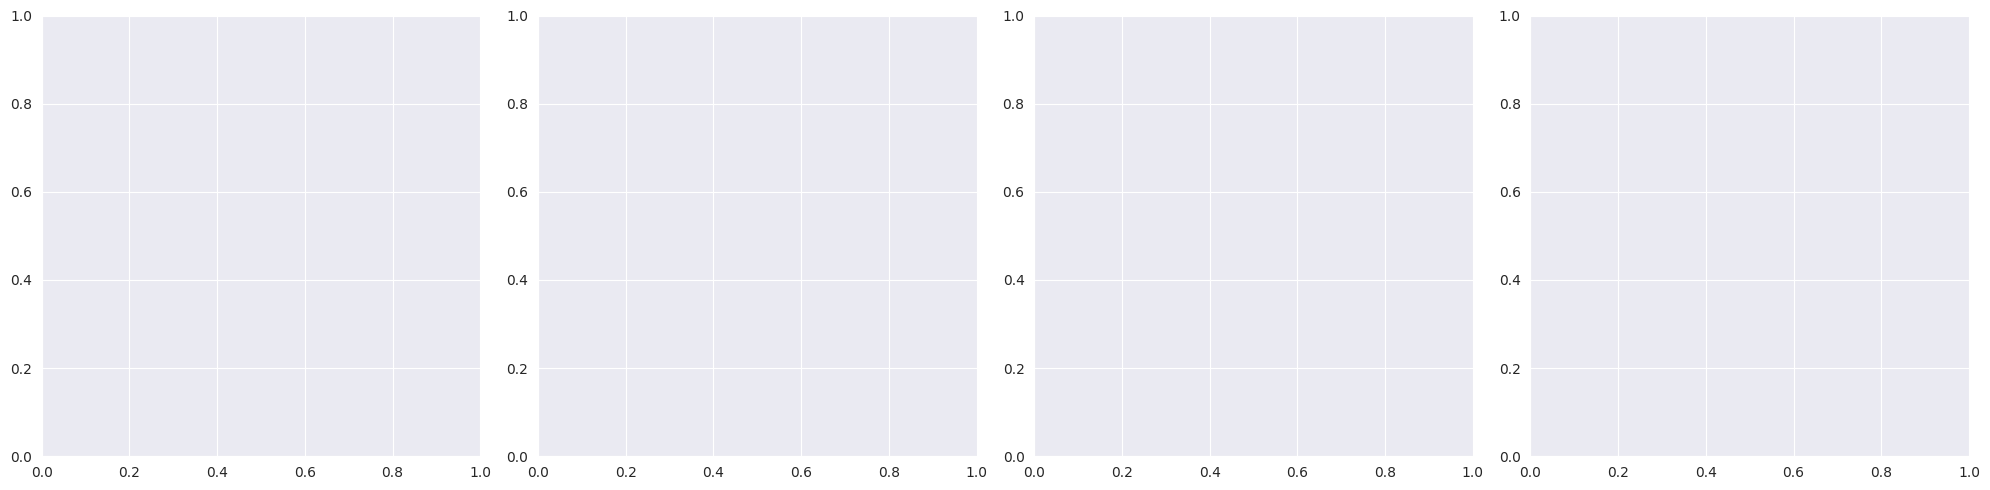

In [9]:
g = sns.relplot(
    data=discrete_df,
    x="iteration",
    y="fitness",
    col="problem",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

In [10]:
final_cgp_data = discrete_df[discrete_df.groupby(["problem"])["iteration"].transform(max) == discrete_df["iteration"]][
    ["problem", "fitness", "solver"]]
final_rl_data = rl_df[rl_df.groupby(["env_id", "seed"])["global_step"].transform(max) == rl_df["global_step"]][
    ["env_id", "charts/episodic_return"]]
final_rl_data.columns = ["problem", "fitness"]
final_rl_data["solver"] = "RL"
final_data = pd.concat([final_cgp_data, final_rl_data], ignore_index=True)
final_data.head()

,problem,fitness,solver
0,Acrobot-v1,-70.200005,lgp
1,Acrobot-v1,-68.599998,cgp
2,Acrobot-v1,-68.599998,lgp
3,Acrobot-v1,-68.400002,cgp
4,Acrobot-v1,-69.599998,lgp


In [11]:
sns.boxplot(final_data, x="problem", y="fitness", hue="solver")
plt.show()

/home/giorgianadizar/miniconda3/envs/gpax/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


ValueError: Could not interpret input 'fitness'

In [7]:
from numpy import median
from typing import Union, List
from pandas import DataFrame


def line_plot(df: DataFrame, x: str, y: Union[List[str], str], groups: Union[List[str], str] = None,
              file_prefix: str = "", cols_joiner: str = "_", filename_joiner: str = "_"):
    if isinstance(y, str):
        y = [y]
    if isinstance(groups, str):
        groups = [groups]

    def q1(a):
        return a.quantile(0.25)

    def q3(b):
        return b.quantile(0.75)

    vals = dict([(key, [q1, q3, median]) for key in y])

    summary = df.groupby(groups + [x]).agg(vals)
    summary.columns = [cols_joiner.join(col) for col in summary.columns.to_flat_index()]
    summary.reset_index(inplace=True)

    key_df = df.drop_duplicates(subset=groups)

    for i in range(len(key_df)):
        tmp = summary
        current_filename = file_prefix
        for key in groups:
            tmp = tmp[tmp[key] == key_df[key].iloc[i]]
            current_filename += f"{filename_joiner if len(current_filename) > 0 and not current_filename.endswith('/') else ''}{key_df[key].iloc[i]}"
        tmp.to_csv(f"{current_filename}.txt", sep="\t", index=False)

In [8]:
line_plot(
    discrete_df,
    x="iteration",
    y="fitness",
    groups=["solver", "env"],
    file_prefix="../pgfplots/discrete_fitness_progression"
)

In [9]:
for problem in final_data["problem"].unique():
    processed_env_name = problem.lower().split("-")[0]
    for solver in final_data["solver"].unique():
        tmp_df = final_data[(final_data["problem"] == problem) & (final_data["solver"] == solver)][["fitness"]]
        tmp_df.to_csv(f"../pgfplots/discrete_final_{solver}_{processed_env_name}.txt", sep="\t", index=False)

/tmp/ipykernel_131933/492091641.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')  # 'shading=auto' is important


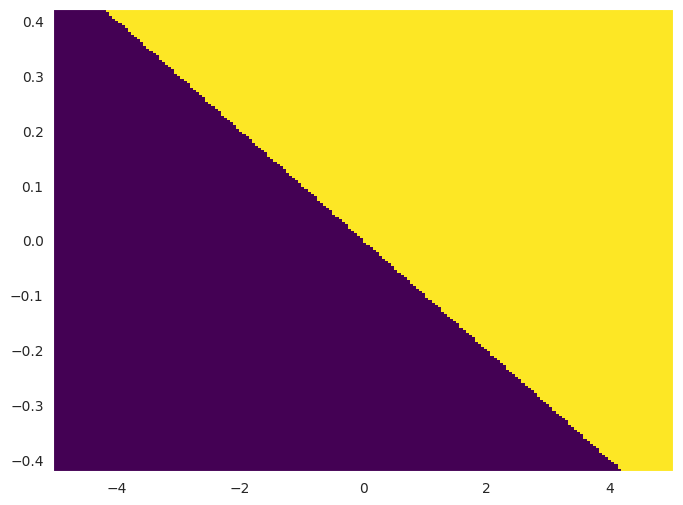

In [8]:
# CGP cart-pole
# o0 = (i0>i0)
# o1 = ((i3*i4)+i2)

n_points = 200
velocity = np.linspace(-5, 5, n_points)
angle = np.linspace(-0.418, 0.418, n_points)
X, Y = np.meshgrid(velocity, angle)
Z = (0.1 * X + Y) > 0
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')  # 'shading=auto' is important
plt.show()

In [ ]:
# LGP cart pole
# o0 = (0-i2)
# o1 = (abs(i4)*i3)
# o1 > o0 -> .1 * i3 > -i2 -> .1 * i3 + i2 > 0

n_points = 200
velocity = np.linspace(-5, 5, n_points)
angle = np.linspace(-0.418, 0.418, n_points)
X, Y = np.meshgrid(velocity, angle)
Z = (0.1 * X + Y) > 0
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')  # 'shading=auto' is important
plt.show()

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


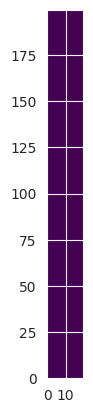

In [25]:
# LGP mountain car
# o0 = exp(i1)<1
# o1 = 1
# o2 = exp(exp(i1))

n_points = 200
i1 = np.linspace(-0.07, 0.07, n_points)
dummy = np.linspace(-1, 1, 20)

out_values = np.zeros((len(i1), len(dummy)), dtype=int)

for x_id, x in enumerate(i1):
    for y_id, y in enumerate(dummy):
        o0 = int(np.exp(x) < 1)
        o1 = 1
        o2 = np.exp(np.exp(x))
        if o0 > o1 and o0 > o2:
            out_values[x_id, y_id] = -1
        elif o1 > o2 and o1 > o2:
            out_values[x_id, y_id] = 0
        else:
            out_values[x_id, y_id] = 1

plt.imshow(out_values, cmap='viridis', origin='lower')
plt.show()